#### What we're doing

This is a HTET script for a 0+1D scalar field theory (quantum mechanics)

We use:

$$H = \frac{1}{2}\Pi^2 + \frac{1}{2}\phi^2 + \lambda \phi^4 $$

Free part is just harmonic oscillator and $\lambda$ term is the interaction term

Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.fft import fft, fftfreq
np.set_printoptions(precision=18, suppress=False)

#### Annihilation and Creation Operators

```N``` is the number of truncated states

standard ladder operators for fock basis {$\ket{0}, \ket{1}, \ket{2},...\ket{N-1},$}

$ a\ket{n} = \sqrt{n}\ket{n-1} ~~~~ a^{\dagger} \ket{n} = \sqrt{n+1}\ket{n+1} $ 

In [2]:
def ladder_ops(N: int):
    a = np.zeros((N, N), dtype=float)
    adag = np.zeros((N,N), dtype=float)
    for n in range(1, N):
        a[n - 1, n] = np.sqrt(n)
    for n in range(0, N-1):
        adag[n+1, n] = np.sqrt(n+1)
    return a, adag


In [3]:
ladder_operators = ladder_ops(5)

print("a:")
print(ladder_operators[0])
print("~" * 20)
print("adag:")
print(ladder_operators[1])

a:
[[0.                 1.                 0.
  0.                 0.                ]
 [0.                 0.                 1.4142135623730951
  0.                 0.                ]
 [0.                 0.                 0.
  1.7320508075688772 0.                ]
 [0.                 0.                 0.
  0.                 2.                ]
 [0.                 0.                 0.
  0.                 0.                ]]
~~~~~~~~~~~~~~~~~~~~
adag:
[[0.                 0.                 0.
  0.                 0.                ]
 [1.                 0.                 0.
  0.                 0.                ]
 [0.                 1.4142135623730951 0.
  0.                 0.                ]
 [0.                 0.                 1.7320508075688772
  0.                 0.                ]
 [0.                 0.                 0.
  2.                 0.                ]]


#### Construct $\phi$ and $\Pi$

```omega``` is the input frequency

$$\phi = \frac{a+a^{\dagger}}{\sqrt{2\omega}}$$

$$\Pi = \sqrt{\frac{\omega}{2}} (a^{\dagger}-a) $$

In [4]:
def ho_operators(N: int, omega: float):
    a, adag = ladder_ops(N)
    phi = (a + adag) / np.sqrt(2.0 * omega)
    pi = 1j * np.sqrt(omega / 2.0) * (adag - a)
    return phi, pi, a, adag


In [5]:
phi, pi, a, adag = ho_operators(6, 1)

print("phi:")
print(phi)
print("~" * 20)
print("phi^2:")
print(2* phi @ phi)
print("~" * 20)
print("phi^4:")
print(4 * phi @ phi @ phi @ phi)

phi:
[[0.                 0.7071067811865475 0.
  0.                 0.                 0.                ]
 [0.7071067811865475 0.                 1.
  0.                 0.                 0.                ]
 [0.                 1.                 0.
  1.224744871391589  0.                 0.                ]
 [0.                 0.                 1.224744871391589
  0.                 1.414213562373095  0.                ]
 [0.                 0.                 0.
  1.414213562373095  0.                 1.5811388300841895]
 [0.                 0.                 0.
  0.                 1.5811388300841895 0.                ]]
~~~~~~~~~~~~~~~~~~~~
phi^2:
[[0.9999999999999998 0.                 1.414213562373095
  0.                 0.                 0.                ]
 [0.                 3.                 0.
  2.449489742783178  0.                 0.                ]
 [1.414213562373095  0.                 4.999999999999999
  0.                 3.464101615137754  0.            

#### Full Hamiltonian

This is the free and interacting parts of the hamiltonian in the HO basis

In [6]:
def build_H0(N: int, omega: float):
    phi, pi, _, _ = ho_operators(N, omega)
    return 0.5 * (pi @ pi) + 0.5 * omega**2 * (phi @ phi)

def build_V(N: int, omega: float, lam: float):
    phi, _, _, _ = ho_operators(N, omega)
    phi2 = phi @ phi
    phi4 = phi2 @ phi2
    V_mass = 0.5 * (1.0 - omega**2) * phi2
    V_x4   = (lam / 24.0) * phi4
    return V_mass + V_x4

def build_full_H(N: int, omega: float, lam: float):
    return build_H0(N, omega) + build_V(N, omega, lam)

##### Defines the UV cutoff on the Hamiltonian

- Assumes HO free Hamiltonian
- Uses known analytic spectrum
- splits basis into low energy and high energy sectors P and Q respectively

inputs:
```omega``` is the input frequency 

```Emax``` is the UV cutoff

```N_uv``` is the regulator of the space size not the HTET cutoff

In [7]:
def indices_below_Emax(omega: float, Emax: float, N_uv: int):
    n = np.arange(N_uv)
    En = omega * (n + 0.5)
    P = np.where(En <= Emax)[0]
    Q = np.where(En > Emax)[0]
    return P, Q, En

#### Building the effective Hamiltonian

The Hamiltonian constructed here acts only within the low energy space P but includes effects of the excluded high energy space Q through the HTET matching correction at $O(V^2)$:

$$H_{eff}=P(H_0+V)P + H_2 ~~~~~ (H_2)_{fi} = \sum_{\alpha \in Q} \frac{V_{f\alpha}V_{\alpha i}}{E_f - E_\alpha}$$

THe function returns (Heff, P, Q) where Heff is the P space effective Hamiltonian matched through O(V^2) using Cohen 2.23b.

Also in general this is non hermitian which is expected from Cohen

##### Second Order H:

In [8]:
def naive_Heff(N_uv: int, omega: float, lam: float, Emax: float):
    #build H0 and V in the truncated basis
    #gives the "fundamental data" needed for matching
    H0 = build_H0(N_uv, omega)
    V = build_V(N_uv, omega, lam)

    P, Q, En = indices_below_Emax(omega, Emax, N_uv)
    nP = len(P)
    #checking we actually have P states to use
    if nP == 0:
        raise ValueError("Emax too small: P-space is empty.")

    # Project to blocks
    # our original is built from H0_PP and V_PP
    # our correction is built from V_PQ and V_QP
    H0_PP = H0[np.ix_(P, P)] #P H0 P
    V_PP = V[np.ix_(P, P)] #P V P
    V_PQ = V[np.ix_(P, Q)] #P V Q
    V_QP = V[np.ix_(Q, P)] # Q V P

    # We build the "naive truncation" (PHP)
    Heff = H0_PP + V_PP
    Heff = 0.5 * (Heff + Heff.conj().T)

    return Heff, P, Q, H0, V

In [9]:
def htet_Heff_O_V2(N_uv: int, omega: float, lam: float, Emax: float):
    
    #build H0 and V in the truncated basis
    #gives the "fundamental data" needed for matching
    H0 = build_H0(N_uv, omega)
    V = build_V(N_uv, omega, lam)

    P, Q, En = indices_below_Emax(omega, Emax, N_uv)
    nP = len(P)
    #checking we actually have P states to use
    if nP == 0:
        raise ValueError("Emax too small: P-space is empty.")

    # Project to blocks
    # our original is built from H0_PP and V_PP
    # our correction is built from V_PQ and V_QP
    H0_PP = H0[np.ix_(P, P)] #P H0 P
    V_PP = V[np.ix_(P, P)] #P V P
    V_PQ = V[np.ix_(P, Q)] #P V Q
    V_QP = V[np.ix_(Q, P)] # Q V P

    # We build the "naive truncation" (PHP)
    Heff = H0_PP + V_PP

    # set up construction of H2
    H2 = np.zeros((nP, nP), dtype=complex)

    #pull out the H0 energies for P and Q (for denominators)
    EP = En[P]  # energies for P states (H0) -  EP[f] is the free energy of the P state |f>
    EQ = En[Q]  # energies for Q states (H0) - EP[a] is the freee energy of the Q state |a>

    # Compute correction row by row
    for f in range(nP):
        Ef = EP[f] # fix final p state |f>
        inv = 1.0 / (Ef - EQ) # build denominators
        H2[f, :] = (V_PQ[f, :] * inv) @ V_QP # construct correction

    Heff = Heff + H2
    Heff = 0.5 * (Heff + Heff.conj().T)
    
    return Heff, P, Q, H0, V # theres the full effective hamiltonian :)

##### Third order H

We can include higher order H by doing 

$$H_{eff}= P(H_0+V)P + H_2 + H_3$$

where 

$$ (H_3)_{fi} = \sum_{\alpha,\beta \in Q} \frac{V_{f \alpha} V_{\alpha \beta} V_{\beta i}}{(E_f - E_\alpha)(E_f-E_\beta)} - \sum_{\alpha \in P} \sum_{\beta \in Q}\frac{V_{f \alpha} V_{\alpha \beta} V_{\beta i}}{(E_\alpha - E_\beta)(E_f-E_\beta)} $$


Should make a note here to say this actually heavily uses projectors as in the actual form Im using isnt the above it's more similar to:

$$ H_3(E_f) = PVQ \frac{1}{E_f - H_0} QVQ \frac{1}{E_f - H_0} QVP - PVP \frac{1}{E_P - H_0} PVQ \frac{1}{E_f - H_0} QVP $$


where we construct P and Q implicity by constructing block matrices of V, $H_0$ is the solvable free energy,explicitly:  PVQ starts in thehigh energy space, acts with V and projects into the low energy space, QVP is the inverse of this, QVQ is the interaction restricted to the high energy subspace and similarly PVP is the retained low energy space, $\frac{1}{E_f - H_0}$ is equivalent to the denominators $\frac{1}{E_f-E_\alpha}$ and similarly $\frac{1}{E_P - H_0} \to \frac{1}{E_\alpha - E_\beta}$ 

In [10]:
def htet_Heff_O_V3(N_uv: int, omega: float, lam: float, Emax: float):
    Heff, P, Q, H0, V = htet_Heff_O_V2(N_uv, omega, lam, Emax)

    _, _, En = indices_below_Emax(omega, Emax, N_uv)

    nP = len(P)
    nQ = len(Q)
    if nP == 0:
        raise ValueError("Emax too small: P-space is empty.")
    if nQ == 0:
        # No high energy states mean no matching correction
        return Heff, P, Q, H0, V

    # Blocks of V
    V_PP = V[np.ix_(P, P)]  # (nP, nP) 
    V_PQ = V[np.ix_(P, Q)]  # (nP, nQ) 
    V_QP = V[np.ix_(Q, P)]  # (nQ, nP) 
    V_QQ = V[np.ix_(Q, Q)]  # (nQ, nQ)

    H3 = np.zeros((nP, nP), dtype=complex)

    EP = En[P]   # shape (nP,)
    EQ = En[Q]   # shape (nQ,)

    denom_PQ = EP[:, None] - EQ[None, :] # shape (nP, nQ)
    A = V_PQ / denom_PQ # useful easy prefactor

    for f in range(nP):
        Ef = EP[f]
        inv_f = 1.0 / (Ef - EQ) # new factor

        #first term
        tmp_b = (V_PQ[f, :] * inv_f) @ V_QQ  # shape (nQ,)
        # multiply by 1/(Ef-Eb) and sum into i via V_bi
        term1_row = (tmp_b * inv_f) @ V_QP   # shape (nP,)

        #second term (we use the A we made previously)
        s_b = V_PP[f, :] @ A                 # shape (nQ,)
        term2_row = (s_b * inv_f) @ V_QP     # shape (nP,)

        H3[f, :] = term1_row - term2_row


    Heff3 = Heff + H3 # final effective hamiltonian
    Heff3 = 0.5 * (Heff3 + Heff3.conj().T)
    
    return Heff3, P, Q, H0, V

#### GS energy

Computes eigenvalues of of H then gives the minimum 

In [11]:
def ground_state_energy_from_matrix(H, level=0):
    evals = np.linalg.eigvalsh(H)
    if level >= len(evals):
        raise ValueError(
            f"Requested level={level}, but matrix has only {len(evals)} eigenvalues."
        )
    return evals[level], evals

##### Run of functions and raw comparison

In [12]:
def run_energy_scan(heff: str, omega=1.0, lam=1.0,
                    Emax_list=(1.0, 2.0, 3.0, 4.0, 5.0),
                    Known_E=1.0, print_table=True, level=0):

    rows = []

    if print_table:
        print(f"lambda(Cohen)={lam}")
        print("Emax | dim(P) | E_raw | E_HTET | percentage error")
        print("-" * 70)

    Heff_dict = {
        "H1": naive_Heff,
        "H2": htet_Heff_O_V2,
        "H3": htet_Heff_O_V3
    }

    for Emax in Emax_list:
        N_uv = int(np.ceil(Emax + 10))

        H_full = build_full_H(N_uv, omega, lam)
        P, Q, En = indices_below_Emax(omega, Emax, N_uv)
        nP = len(P)

        # Skip points where requested level does not exist in P-space
        if nP <= level:
            continue

        H_raw = H_full[np.ix_(P, P)]
        E_raw, _ = ground_state_energy_from_matrix(H_raw, level)

        H_htet, _, _, _, _ = Heff_dict[heff](N_uv, omega, lam, Emax)

        # Extra safety: check actual HTET matrix size too
        if H_htet.shape[0] <= level:
            continue

        E_htet, _ = ground_state_energy_from_matrix(H_htet, level)

        diff = Known_E - E_htet
        percentage_error = 100 * abs((Known_E - E_htet) / Known_E)

        rows.append([Emax, nP, E_raw, E_htet, percentage_error, diff])

        if print_table:
            print(f"{Emax:4.1f} | {nP:6d} | "
                  f"{E_raw.real: .10f},{E_raw.imag: .2e} | "
                  f"{E_htet.real: .10f},{E_htet.imag: .2e} | "
                  f"{percentage_error: .2e}")

    return np.array(rows, dtype=np.float64)

In [13]:
def run_omega_scan(heff: str, omega_list=(1.0,2.0,3.0,4.0,5.0), lam=1.0,
                   N_uv=200, Emax=50.0, Known_E=1.0, print_table=True, level=0):

    rows = []

    if print_table:
        print(f"lambda(Cohen)={lam}")
        print("Emax | dim(P) | E_raw | E_HTET | percentage error | omega")
        print("-" * 70)

    Heff_dict = {
        "H1": naive_Heff,
        "H2": htet_Heff_O_V2,
        "H3": htet_Heff_O_V3
    }

    for omega in omega_list:
        H_full = build_full_H(N_uv, omega, lam)
        P, Q, En = indices_below_Emax(omega, Emax, N_uv)
        nP = len(P)

        # skip points where requested eigenlevel is not present
        if nP <= level:
            continue

        H_raw = H_full[np.ix_(P, P)]
        E_raw, _ = ground_state_energy_from_matrix(H_raw, level)

        H_htet, _, _, _, _ = Heff_dict[heff](N_uv, omega, lam, Emax)
        E_htet, _ = ground_state_energy_from_matrix(H_htet, level)

        diff = Known_E - E_htet
        percentage_error = 100 * abs((Known_E - E_htet) / Known_E)

        rows.append([Emax, nP, E_raw, E_htet, percentage_error, omega, diff])

        if print_table:
            print(f"{Emax:4.1f} | {nP:6d} | "
                  f"{E_raw.real: .10f},{E_raw.imag: .2e} | "
                  f"{E_htet.real: .10f},{E_htet.imag: .2e} | "
                  f"{percentage_error: .2e} | {omega}")

    return np.array(rows, dtype=np.float64)

In [14]:
#Es for lambda = 1
E0 = 0.52773612731410831269035109114701621561393954399308
E1 = 1.631300532768307447535797641299407409666056688344
E2 = 2.8221895629546794107586487866983585728937188414279
E3 = 4.0860289543126751347062043012369318729517761811902
level = 3
reference_E = E3
nQ_list = (2,3,4,5,6,7,8,9)


best error for H3 is 0.0006059781833702377
best error for H2 is 0.0018744822403294551
best error for H1 is 0.003633123570242685


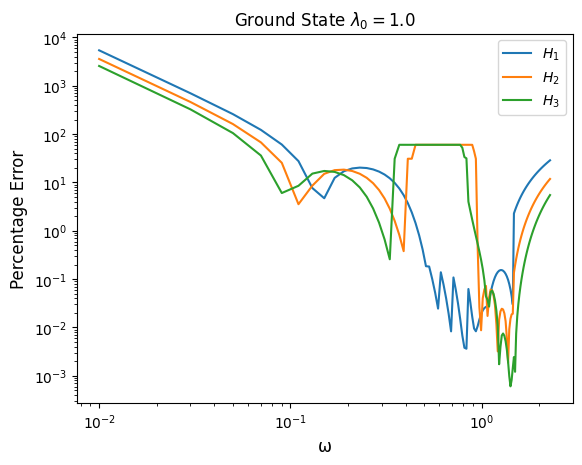

In [15]:
omega_list = list(np.linspace(0.01,10,500))
nQ = 3
Emax = 2**nQ
H_list = ["H1", "H2", "H3"]
Emax_list = [8,16,32]
fontsize = 12

N_uv1 = Emax + 8
N_uv2 = Emax + 12
N_uv3 = Emax + 16

O_results_H1 =run_omega_scan(
    heff="H1",
    omega_list=omega_list,
    lam=1.0,
    N_uv=N_uv1,
    Emax=Emax, 
    Known_E=reference_E,
    print_table=False,
    level = level
    )

O_results_H2 =run_omega_scan(
    heff="H2",
    omega_list=omega_list,
    lam=1.0,
    N_uv=N_uv2,
    Emax=Emax, 
    Known_E=reference_E,
    print_table=False,
    level = level
    )

O_results_H3 =run_omega_scan(
    heff="H3",
    omega_list=omega_list,
    lam=1.0,
    N_uv=N_uv3,
    Emax=Emax, 
    Known_E=reference_E,
    print_table=False,
    level = level
    )

print(f"best error for H3 is {min(O_results_H3[:, 4])}")
print(f"best error for H2 is {min(O_results_H2[:, 4])}")
print(f"best error for H1 is {min(O_results_H1[:, 4])}")

plt.loglog(O_results_H1[:, 5], O_results_H1[:, 4], label = r"$H_1$")
plt.loglog(O_results_H2[:, 5], O_results_H2[:, 4], label = r"$H_2$")
plt.loglog(O_results_H3[:, 5], O_results_H3[:, 4], label = r"$H_3$")
plt.xlabel("ω", fontsize = fontsize)
plt.ylabel("Percentage Error", fontsize = fontsize)
plt.title(r"Ground State $\lambda_0 = 1.0$")
plt.legend()
plt.show()

best error for H3 is 1.2553093556408802050256354227331535150513630583191115874797105789184570312500000000000000000000000000e-10 at 39.36112224448898
best error for H2 is 1.2553093556408802050256354227331535150513630583191115874797105789184570312500000000000000000000000000e-10 at 39.36112224448898
best error for H1 is 1.2553093556408802050256354227331535150513630583191115874797105789184570312500000000000000000000000000e-10 at 39.36112224448898


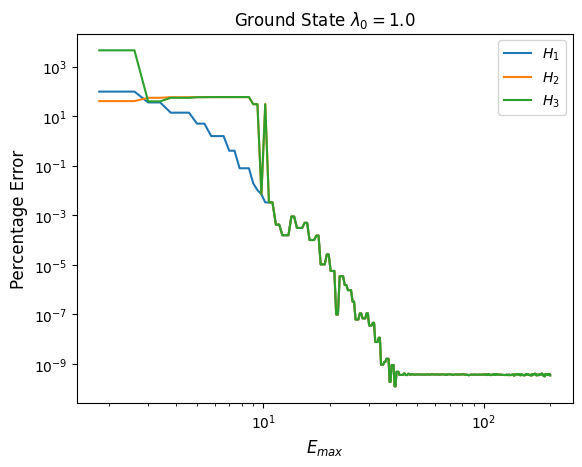

In [16]:
Emax_List = list(np.linspace(0.6, 200, 500))
omega = 0.5


E_results_H1 =run_energy_scan(
    heff="H1",
    omega=omega,
    lam=1.0,
    Emax_list=Emax_List, 
    Known_E=reference_E,
    print_table=False,
    level = level
    )

E_results_H2 =run_energy_scan(
    heff="H2",
    omega=omega,
    lam=1.0,
    Emax_list=Emax_List, 
    Known_E=reference_E,
    print_table=False,
    level = level
    )

E_results_H3 =run_energy_scan(
    heff="H3",
    omega=omega,
    lam=1.0,
    Emax_list=Emax_List, 
    Known_E=reference_E,
    print_table=False,
    level = level
    )

print(f"best error for H3 is {min(E_results_H3[:, 4]):.100e} at {E_results_H3[np.argmin(E_results_H3[:, 4]), 0]}")
print(f"best error for H2 is {min(E_results_H2[:, 4]):.100e} at {E_results_H2[np.argmin(E_results_H2[:, 4]), 0]}")
print(f"best error for H1 is {min(E_results_H1[:, 4]):.100e} at {E_results_H1[np.argmin(E_results_H1[:, 4]), 0]}")

plt.loglog(E_results_H1[:, 0], E_results_H1[:, 4], label = r"$H_1$")
plt.loglog(E_results_H2[:, 0], E_results_H2[:, 4], label = r"$H_2$")
plt.loglog(E_results_H3[:, 0], E_results_H3[:, 4], label = r"$H_3$")

plt.xlabel(r"$E_{max}$", fontsize = fontsize)
plt.ylabel("Percentage Error", fontsize = fontsize)
plt.title(r"Ground State $\lambda_0 = 1.0$")
plt.legend()
plt.show()


In [17]:
def run_emax_omega_scan(
    heff: str,
    omega_list=(1.0, 2.0, 3.0),
    lam=1.0,
    Emax_list=(5.0, 10.0, 15.0),
    Known_E=1.0,
    print_table=True,
    level=0
):
    rows = []

    if print_table:
        print(f"lambda(Cohen) = {lam}")
        print("Emax | omega | dim(P) | E_raw | E_HTET | percentage error")
        print("-" * 90)

    Heff_dict = {
        "H1": naive_Heff,
        "H2": htet_Heff_O_V2,
        "H3": htet_Heff_O_V3
    }

    for Emax in Emax_list:
        for omega in omega_list:
            N_uv = int(np.ceil(Emax + 10))

            H_full = build_full_H(N_uv, omega, lam)
            P, Q, En = indices_below_Emax(omega, Emax, N_uv)
            nP = len(P)

            # Default row values
            E_raw = np.nan
            E_htet = np.nan
            percentage_error = np.nan
            diff = np.nan

            # Only compute if requested level exists in raw P-space
            if nP > level:
                H_raw = H_full[np.ix_(P, P)]
                E_raw, _ = ground_state_energy_from_matrix(H_raw, level)

                H_htet, _, _, _, _ = Heff_dict[heff](N_uv, omega, lam, Emax)

                # Only compute HTET level if it also exists there
                if H_htet.shape[0] > level:
                    E_htet, _ = ground_state_energy_from_matrix(H_htet, level)
                    diff = Known_E - E_htet
                    percentage_error = 100 * abs((Known_E - E_htet) / Known_E)

            rows.append([Emax, omega, nP, E_raw, E_htet, percentage_error, diff])

            if print_table:
                e_raw_str = f"{E_raw.real: .10f}" if np.isfinite(E_raw) else "nan"
                e_htet_str = f"{E_htet.real: .10f}" if np.isfinite(E_htet) else "nan"
                err_str = f"{percentage_error: .2e}" if np.isfinite(percentage_error) else "nan"

                print(f"{Emax:6.2f} | {omega:6.2f} | {nP:6d} | "
                      f"{e_raw_str} | {e_htet_str} | {err_str}")

    return np.array(rows, dtype=np.float64)

Emax2 = list(np.linspace(5, 100, 100))
omega2 = list(np.linspace(0.5, 10, 100))

for H in ["H1", "H2", "H3"]:
    E_omega_results = run_emax_omega_scan(
        heff=H,
        omega_list=omega2,
        lam=1.0,
        Emax_list=Emax2, 
        Known_E=reference_E,
        print_table=False,
        level = level
    )

    res = E_omega_results

    Emax_vals  = np.unique(res[:, 0])
    omega_vals = np.unique(res[:, 1])

    if res.shape[0] != len(Emax_vals) * len(omega_vals):
        raise ValueError(
            f"Not a full grid: got {res.shape[0]} rows, but "
            f"{len(omega_vals)}*{len(Emax_vals)}={len(omega_vals)*len(Emax_vals)} expected."
        )

    order = np.lexsort((res[:, 0], res[:, 1]))  # primary sort by omega, secondary by Emax
    res_sorted = res[order]

    Z = res_sorted[:, 2].reshape(len(omega_vals), len(Emax_vals))  # rows=omega, cols=Emax
    X, Y = np.meshgrid(Emax_vals, omega_vals)

    min_index = np.argmin(Z)
    row, col = np.unravel_index(min_index, Z.shape)

    min_error = Z[row, col]
    best_omega = omega_vals[row]
    best_Emax = Emax_vals[col]
    median_log_error = 10**(np.median(np.log10(Z)))
    std_error = np.std(Z)

    print(f"\n{H}:")
    print(f"Minimum relative error = {min_error}")
    print(f"Occurs at Emax = {best_Emax}, Omega = {best_omega}")
    print(f"Median relative error  = {median_log_error} with std = {std_error}")

    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot(111, projection="3d")

    surf = ax.plot_surface(X, Y, Z, linewidth=0, antialiased=True)

    ax.set_title(f"{H} 0+1D")
    ax.set_xlabel("Emax")
    ax.set_ylabel("Omega")
    ax.set_zlabel("Percentage error")
    ax.set_zscale("log")

    plt.tight_layout()

    ax.view_init(elev=30, azim=75)

    plt.show()




Large spikes are caused by:
- the poles in the denominators $\frac{1}{E-H}$
- Discrete changes in P space when Emax crosses into a new HO level
- Big range of percentage errors exagerate the effects


H1:
Minimum Perecentage error = 1.0
Occurs at Emax = 5.0, Omega = 3.3787878787878785
Median Percentage error  = 10.0 with std = 18.198508702638247


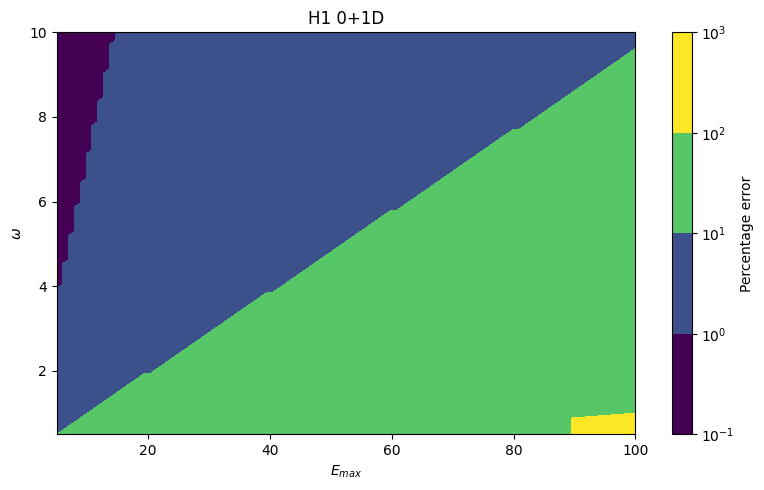


H2:
Minimum Perecentage error = 1.0
Occurs at Emax = 5.0, Omega = 3.3787878787878785
Median Percentage error  = 10.0 with std = 18.198508702638247


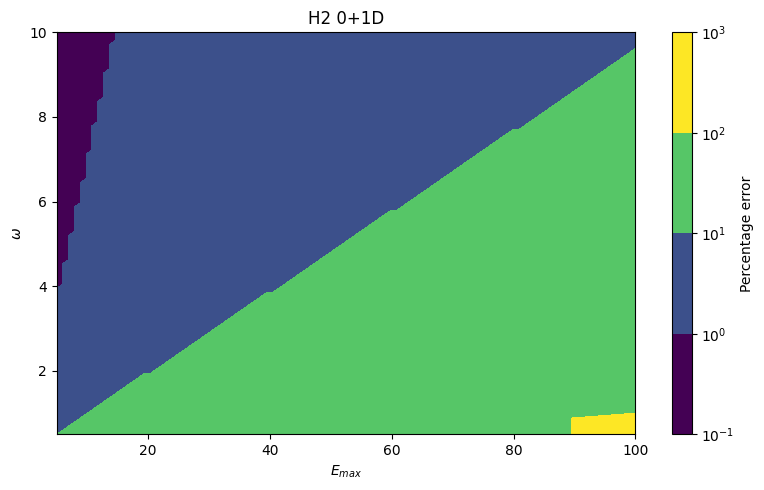


H3:
Minimum Perecentage error = 1.0
Occurs at Emax = 5.0, Omega = 3.3787878787878785
Median Percentage error  = 10.0 with std = 18.198508702638247


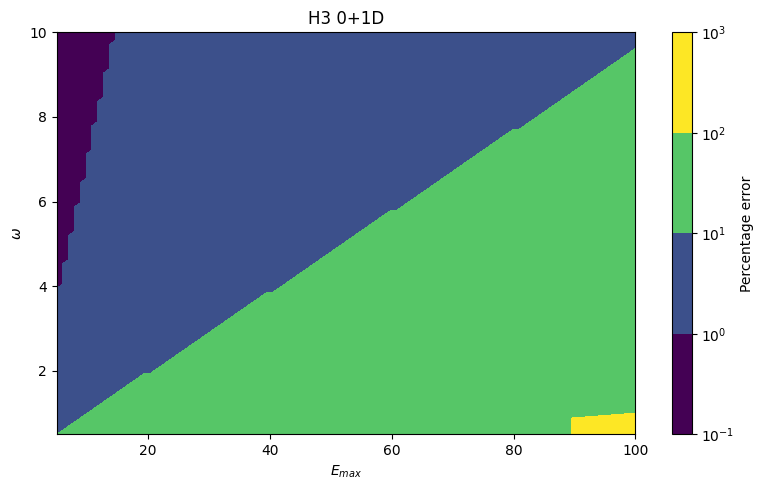

In [18]:
Emax2  = list(np.linspace(5, 100, 100))
omega2 = list(np.linspace(0.5, 10, 100))

# plotting controls
Z_FLOOR = 0 # avoids log10(0), set smaller if needed
CLIP_MAX = None # e.g. 1.0 to cap at 100% error, or None for no clipping, for getting rid of poles
N_LEVELS = 100 # contour resolution
USE_LOG_COLOR = True # log-scale via LogNorm

for H in ["H1", "H2", "H3"]:
    res = run_emax_omega_scan(
        heff=H,
        omega_list=omega2,
        lam=1.0,
        Emax_list=Emax2,
        Known_E=reference_E,
        print_table=False,
        level = level
    )

    # Extract grid axes
    Emax_vals  = np.unique(res[:, 0])
    omega_vals = np.unique(res[:, 1])

    # Validate full grid
    if res.shape[0] != len(Emax_vals) * len(omega_vals):
        raise ValueError(
            f"Not a full grid: got {res.shape[0]} rows, but "
            f"{len(omega_vals)}*{len(Emax_vals)}={len(omega_vals)*len(Emax_vals)} expected."
        )

    # Sort so reshape is consistent: rows=omega, cols=Emax
    order = np.lexsort((res[:, 0], res[:, 1]))  # primary omega, secondary Emax
    res_sorted = res[order]

    Z = res_sorted[:, 2].reshape(len(omega_vals), len(Emax_vals))  # (omega, Emax)
    X, Y = np.meshgrid(Emax_vals, omega_vals)

    # Treat non-finite and non-positive as missing, then floor for plotting
    Z_plot = Z.astype(float)
    Z_plot[~np.isfinite(Z_plot)] = np.nan
    Z_plot[Z_plot <= 0] = np.nan

    # Optional clipping of extreme spikes (presentation-only)
    if CLIP_MAX is not None:
        Z_plot = np.minimum(Z_plot, CLIP_MAX)

    # For log color scaling, we need positive numbers everywhere we plot
    Z_plot_filled = np.where(np.isnan(Z_plot), Z_FLOOR, Z_plot)
    Z_plot_filled = np.maximum(Z_plot_filled, Z_FLOOR)

    # Min location should be computed on the *physical* (unfilled) valid region
    valid = np.isfinite(Z) & (Z > 0)
    if np.any(valid):
        min_flat = np.nanargmin(np.where(valid, Z, np.nan))
        row, col = np.unravel_index(min_flat, Z.shape)
        min_error = Z[row, col]
        best_omega = omega_vals[row]
        best_Emax = Emax_vals[col]
    else:
        min_error = np.nan
        best_omega = np.nan
        best_Emax = np.nan

    # Summary stats (log-median on valid region)
    Z_valid = Z[valid]
    median_log_error = 10 ** (np.median(np.log10(Z_valid))) if Z_valid.size else np.nan
    std_error = np.std(Z_valid) if Z_valid.size else np.nan

    print(f"\n{H}:")
    print(f"Minimum Perecentage error = {min_error}")
    print(f"Occurs at Emax = {best_Emax}, Omega = {best_omega}")
    print(f"Median Percentage error  = {median_log_error} with std = {std_error}")

    # contour heatmap
    fig, ax = plt.subplots(figsize=(8, 5))

    if USE_LOG_COLOR:
        from matplotlib.colors import LogNorm
        norm = LogNorm(vmin=np.nanmin(Z_plot_filled), vmax=np.nanmax(Z_plot_filled))
        cf = ax.contourf(X, Y, Z_plot_filled, levels=N_LEVELS, norm=norm)
        cbar = fig.colorbar(cf, ax=ax)
        cbar.set_label("Percentage error")
    else:
        cf = ax.contourf(X, Y, Z_plot_filled, levels=N_LEVELS)
        cbar = fig.colorbar(cf, ax=ax)
        cbar.set_label("Percentage error")

   

    ax.set_title(f"{H} 0+1D")
    ax.set_xlabel(r"$E_{max}$")
    ax.set_ylabel(r"$\omega$")

    plt.tight_layout()
    plt.show()